# Notebook 05 – Profile Interpretation

## Objective

This notebook integrates the participant engagement profiles identified through unsupervised clustering with quantitative behavioural measures and NLP-derived therapist sentiment. The aim is to characterise the identified engagement profiles, examine whether therapist sentiment differs across profiles, explore relationships between sentiment and quantitative engagement measures, and investigate participant characteristics associated with profile membership.

The analysis is designed to address the remaining research questions concerning behavioural differences between engagement profiles, participant characteristics associated with profile membership, and relationships between NLP-derived sentiment and quantitative engagement measures.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Define Project Paths

Paths to the processed datasets and output figures are defined to maintain a reproducible project structure.

In [2]:
processed_folder = Path("../data/processed")
figures_folder = Path("../figures")

figures_folder.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", processed_folder.resolve())
print("Figures folder:", figures_folder.resolve())

Processed data folder: C:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\data\processed
Figures folder: C:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\figures


## 3. Load Analysis Datasets

The participant-level clustering results and NLP-enriched quantitative feature dataset were loaded from the processed data directory. These datasets will be validated and merged using the participant identifier before conducting profile interpretation.

In [3]:
cluster_path = processed_folder / "clustered_participant_data.csv"
nlp_path = processed_folder / "participant_features_with_nlp.csv"

cluster_df = pd.read_csv(cluster_path)
nlp_features_df = pd.read_csv(nlp_path)

print("Clustering dataset shape:", cluster_df.shape)
print("NLP-enriched dataset shape:", nlp_features_df.shape)

print("\nClustering dataset:")
display(cluster_df.head())

print("\nNLP-enriched dataset:")
display(nlp_features_df.head())

Clustering dataset shape: (32, 20)
NLP-enriched dataset shape: (32, 18)

Clustering dataset:


,Participant id,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage,Cluster_2,Cluster_5,Cluster,Hierarchical_Cluster
0,101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,60.0000,51.904762,0,3,0,0
1,102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833,1,1,1,1
2,104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000,1,1,1,1
3,105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000,0,0,0,0
4,106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619,1,1,1,1



NLP-enriched dataset:


,Participant id,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage,Number_of_text_sessions,Mean_sentiment_compound
0,101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,NaN,51.904762,NaN,NaN
1,102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833,8.0,0.472013
2,104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000,7.0,0.233414
3,105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000,6.0,0.179550
4,106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619,7.0,-0.153443


In [4]:
print("Clustering shape:", cluster_df.shape)
print("NLP shape:", nlp_features_df.shape)

print(
    "Participant IDs identical:",
    set(cluster_df["Participant id"]) ==
    set(nlp_features_df["Participant id"])
)

print(
    "Duplicate IDs in clustering data:",
    cluster_df["Participant id"].duplicated().sum()
)

print(
    "Duplicate IDs in NLP data:",
    nlp_features_df["Participant id"].duplicated().sum()
)

Clustering shape: (32, 20)
NLP shape: (32, 18)
Participant IDs identical: True
Duplicate IDs in clustering data: 0
Duplicate IDs in NLP data: 0


## 4. Integrate Clustering and NLP Results

The NLP-derived participant-level variables were merged with the clustering dataset using the participant identifier. Only the NLP-specific variables were added because the quantitative participant-level measures were already present in the clustering dataset. This avoids duplication of the existing quantitative features.

In [5]:
analysis_df = cluster_df.merge(
    nlp_features_df[
        [
            "Participant id",
            "Number_of_text_sessions",
            "Mean_sentiment_compound"
        ]
    ],
    on="Participant id",
    how="left"
)

print("Integrated dataset shape:", analysis_df.shape)

analysis_df[
    [
        "Participant id",
        "Cluster",
        "Hierarchical_Cluster",
        "Number_of_text_sessions",
        "Mean_sentiment_compound"
    ]
].head(10)

Integrated dataset shape: (32, 22)


,Participant id,Cluster,Hierarchical_Cluster,Number_of_text_sessions,Mean_sentiment_compound
0,101,0,0,NaN,NaN
1,102,1,1,8.0,0.472013
2,104,1,1,7.0,0.233414
3,105,0,0,6.0,0.179550
4,106,1,1,7.0,-0.153443
5,107,0,0,4.0,0.105375
6,109,0,0,6.0,0.241100
7,110,0,0,6.0,0.587833
8,111,0,0,NaN,NaN
9,112,0,0,6.0,0.297600


## 5. Validation of the Integrated Dataset

The integrated dataset was checked for participant duplication, cluster distribution, and availability of NLP-derived sentiment data before conducting profile-level comparisons.

In [6]:
print("Dataset shape:", analysis_df.shape)

print("\nDuplicate participant IDs:")
print(analysis_df["Participant id"].duplicated().sum())

print("\nFinal cluster sizes:")
print(analysis_df["Cluster"].value_counts().sort_index())

print("\nParticipants with sentiment data by cluster:")
print(
    analysis_df.groupby("Cluster")["Mean_sentiment_compound"]
    .count()
)

print("\nParticipants without sentiment data by cluster:")
print(
    analysis_df.groupby("Cluster")["Mean_sentiment_compound"]
    .apply(lambda x: x.isna().sum())
)

Dataset shape: (32, 22)

Duplicate participant IDs:
0

Final cluster sizes:
Cluster
0    25
1     7
Name: count, dtype: int64

Participants with sentiment data by cluster:
Cluster
0    17
1     6
Name: Mean_sentiment_compound, dtype: int64

Participants without sentiment data by cluster:
Cluster
0    8
1    1
Name: Mean_sentiment_compound, dtype: int64


## 6. Quantitative Profile Comparison

To characterise the two engagement profiles, mean participant-level quantitative measures were compared across the final K-Means clusters. Profile labels were not assigned in advance; instead, the observed behavioural and engagement patterns were used to guide subsequent interpretation of the clusters.

In [7]:
profile_features = [
    "Mean_engagement",
    "Mean_emotional_connection",
    "Mean_verbal_participation",
    "Mean_attention",
    "Mean_enjoyment",
    "Mean_story_understanding",
    "Mean_learning_application",
    "Mean_confidence",
    "Mean_generalisation",
    "Mean_story_recall",
    "Mean_reflection",
    "Mean_real_life_connection",
    "Mean_response_time_seconds",
    "Mean_success_percentage"
]

cluster_profile = (
    analysis_df
    .groupby("Cluster")[profile_features]
    .mean()
    .T
)

cluster_profile.columns = [
    "Cluster_0_Mean",
    "Cluster_1_Mean"
]

cluster_profile["Difference_0_minus_1"] = (
    cluster_profile["Cluster_0_Mean"]
    - cluster_profile["Cluster_1_Mean"]
)

cluster_profile.round(2)

,Cluster_0_Mean,Cluster_1_Mean,Difference_0_minus_1
Mean_engagement,3.21,1.64,1.56
Mean_emotional_connection,2.96,1.40,1.55
Mean_verbal_participation,8.00,3.55,4.45
Mean_attention,3.11,1.78,1.33
Mean_enjoyment,3.07,1.68,1.39
Mean_story_understanding,3.26,1.65,1.61
Mean_learning_application,2.43,0.85,1.58
Mean_confidence,2.57,0.78,1.79
Mean_generalisation,2.27,0.44,1.82
Mean_story_recall,2.80,0.70,2.10



### 6.1 Engagement Profile Labels

The quantitative profile comparison showed a consistent separation between the two clusters. Cluster 0 demonstrated higher mean scores across engagement, emotional connection, verbal participation, attention, enjoyment, story understanding, learning application, confidence, generalisation, story recall, reflection, real-life connection, and success percentage. Cluster 0 also showed a lower mean response time.

Based on these relative patterns, Cluster 0 was descriptively labelled the **Higher Engagement Profile**, while Cluster 1 was labelled the **Lower Engagement Profile**. These labels represent relative differences within the present sample and should not be interpreted as externally validated clinical classifications.

In [8]:
profile_labels = {
    0: "Higher Engagement",
    1: "Lower Engagement"
}

analysis_df["Engagement_Profile"] = (
    analysis_df["Cluster"].map(profile_labels)
)

analysis_df[
    ["Participant id", "Cluster", "Engagement_Profile"]
].head(10)

,Participant id,Cluster,Engagement_Profile
0,101,0,Higher Engagement
1,102,1,Lower Engagement
2,104,1,Lower Engagement
3,105,0,Higher Engagement
4,106,1,Lower Engagement
5,107,0,Higher Engagement
6,109,0,Higher Engagement
7,110,0,Higher Engagement
8,111,0,Higher Engagement
9,112,0,Higher Engagement


### 6.2 Quantitative Comparison of Engagement Profiles

To visualise the characteristics of the two engagement profiles, mean scores were compared across the core engagement, emotional, behavioural, and learning-related dimensions. Variables measured on substantially different scales, including verbal participation, response time, and success percentage, were excluded from this figure and are reported separately.

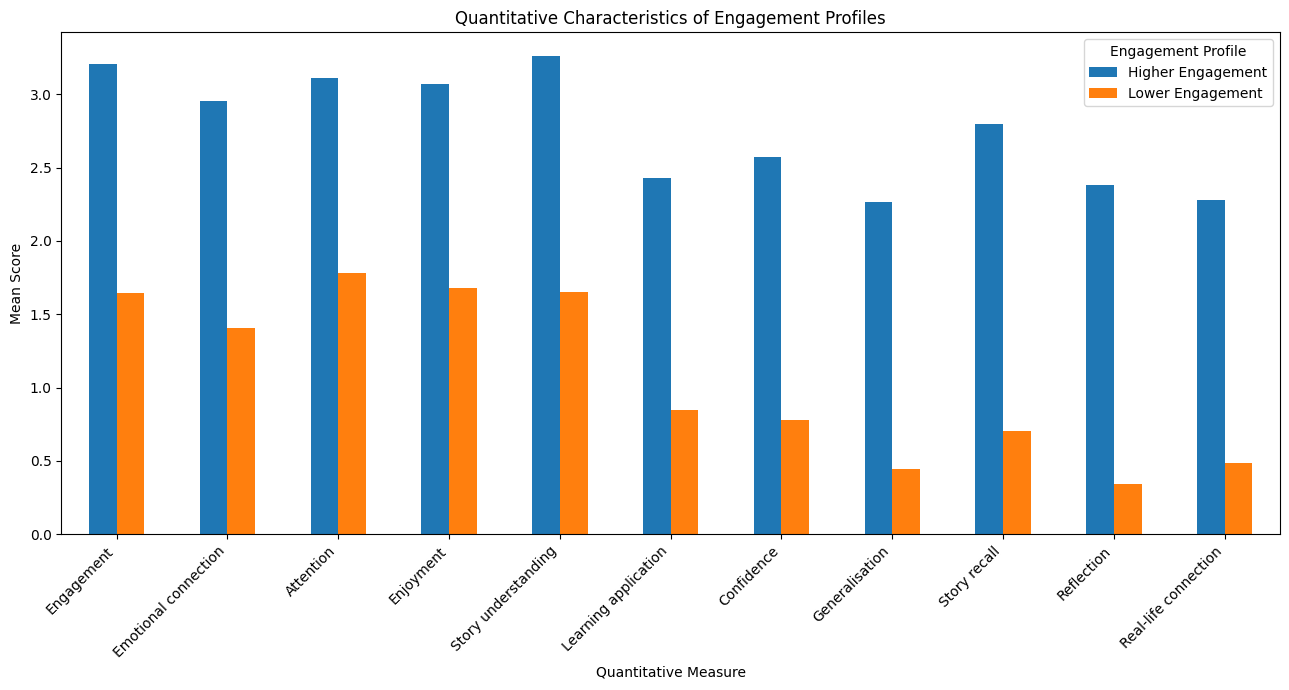

Figure saved: True


In [10]:
profile_plot_features = [
    "Mean_engagement",
    "Mean_emotional_connection",
    "Mean_attention",
    "Mean_enjoyment",
    "Mean_story_understanding",
    "Mean_learning_application",
    "Mean_confidence",
    "Mean_generalisation",
    "Mean_story_recall",
    "Mean_reflection",
    "Mean_real_life_connection"
]

profile_plot = (
    analysis_df
    .groupby("Engagement_Profile")[profile_plot_features]
    .mean()
    .T
)

profile_plot.index = [
    "Engagement",
    "Emotional connection",
    "Attention",
    "Enjoyment",
    "Story understanding",
    "Learning application",
    "Confidence",
    "Generalisation",
    "Story recall",
    "Reflection",
    "Real-life connection"
]

profile_plot.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.xlabel("Quantitative Measure")
plt.ylabel("Mean Score")
plt.title("Quantitative Characteristics of Engagement Profiles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Engagement Profile")

plt.tight_layout()
profile_figure_path = (
    figures_folder / "engagement_profile_quantitative_comparison.png"
)

plt.savefig(
    profile_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure saved:", profile_figure_path.exists())

### 6.3 Additional Profile Characteristics

Verbal participation, success percentage, and response time were examined separately because their measurement scales differed substantially from the other quantitative profile measures. Mean values were compared descriptively between the Higher and Lower Engagement profiles.

In [11]:
additional_features = [
    "Mean_verbal_participation",
    "Mean_success_percentage",
    "Mean_response_time_seconds"
]

additional_profile_summary = (
    analysis_df
    .groupby("Engagement_Profile")[additional_features]
    .agg(["mean", "std", "count"])
    .round(2)
)

additional_profile_summary

Mean_verbal_participation              \
                                        mean   std count   
Engagement_Profile                                         
Higher Engagement                       8.00  1.40    25   
Lower Engagement                        3.55  1.75     7   

                   Mean_success_percentage               \
                                      mean    std count   
Engagement_Profile                                        
Higher Engagement                    74.37  17.67    25   
Lower Engagement                     44.58  23.75     7   

                   Mean_response_time_seconds               
                                         mean    std count  
Engagement_Profile                                          
Higher Engagement                       66.42  45.06    25  
Lower Engagement                        74.96  46.28     7